# RepGeo Visualization

兼容两种 generation 结果：
- 有 `sublayer_metrics`：绘制 `block / attn / mlp` 的 `para_perp_ratio`（均值 + min-max）
- 只有 `layer_metrics`：先绘制 `block`（attn/mlp 无法从该文件恢复）

In [1]:
from pathlib import Path

# ===== config =====
ROOT = Path("/mnt/bn/seed-aws-va/shwai.he/demystifying-transformers-main/results")
RUN_TYPE = "generation"   # "probe" or "generation"
SPACE = "logits"          # "hidden" or "logits"
RANDOM_INIT = False        # False or True
MODE = "both"             # 仅 generation 使用: "prefill"/"decode"/"both"
MAX_NEW_TOKENS = 128
PHASE = MODE

MODEL_NAME = "Mistral-7B-Instruct-v0.3"  
# MODEL_NAME = "Meta-Llama-3-8B-Instruct"  
# MODEL_NAME = "OLMoE-1B-7B-0924-Instruct"  
# MODEL_NAME = "Qwen3-0.6B"  
# MODEL_NAME = "Qwen3-Embedding-0.6B"  
# MODEL_NAME = "Qwen3-30B-A3B"  
# MODEL_NAME = "Llama-3.2-3B"   
# MODEL_NAME = "Olmo-3-7B-Instruct"  
# MODEL_NAME = "Olmo-3-1025-7B"  
# MODEL_NAME = "gemma-3-4b-it"  
# MODEL_NAME = "gemma-3-12b-it"  
# MODEL_NAME = "e5-mistral-7b-instruct"
# MODEL_NAME = "Qwen2.5-7B-Instruct"  
# MODEL_NAME = "Qwen2.5-7B"  # 只改这里

# MODEL_NAME = "Moonlight-16B-A3B"

# MODEL_NAME = "Qwen3-8B"  
# MODEL_NAME = "Qwen3-8B-Base"
# MODEL_NAME = "Qwen3-4B"
MODEL_NAME = "Qwen3-4B-Instruct-2507"  


# ===== config =====

def build_result_path(
    root: Path,
    run_type: str,
    space: str,
    model_name: str,
    random_init: bool = False,
    mode: str = "both",
    max_new_tokens: int = 32,
) -> Path:
    subdir = f"{run_type}_{space}" + ("_random_init" if random_init else "")
    if run_type == "probe":
        filename = f"{model_name}.json"
    else:
        filename = f"{model_name}-mode{mode}-tokens{max_new_tokens}.json"
    return root / subdir / filename

RESULT_PATH = build_result_path(
    root=ROOT,
    run_type=RUN_TYPE,
    space=SPACE,
    model_name=MODEL_NAME,
    random_init=RANDOM_INIT,
    mode=MODE,
    max_new_tokens=MAX_NEW_TOKENS,
)

RESULT_PATH


PosixPath('/mnt/bn/seed-aws-va/shwai.he/demystifying-transformers-main/results/generation_logits/Qwen3-4B-Instruct-2507-modeboth-tokens128.json')

loaded runs: 12 from /mnt/bn/seed-aws-va/shwai.he/demystifying-transformers-main/results/generation_logits/Qwen3-4B-Instruct-2507-modeboth-tokens128.json


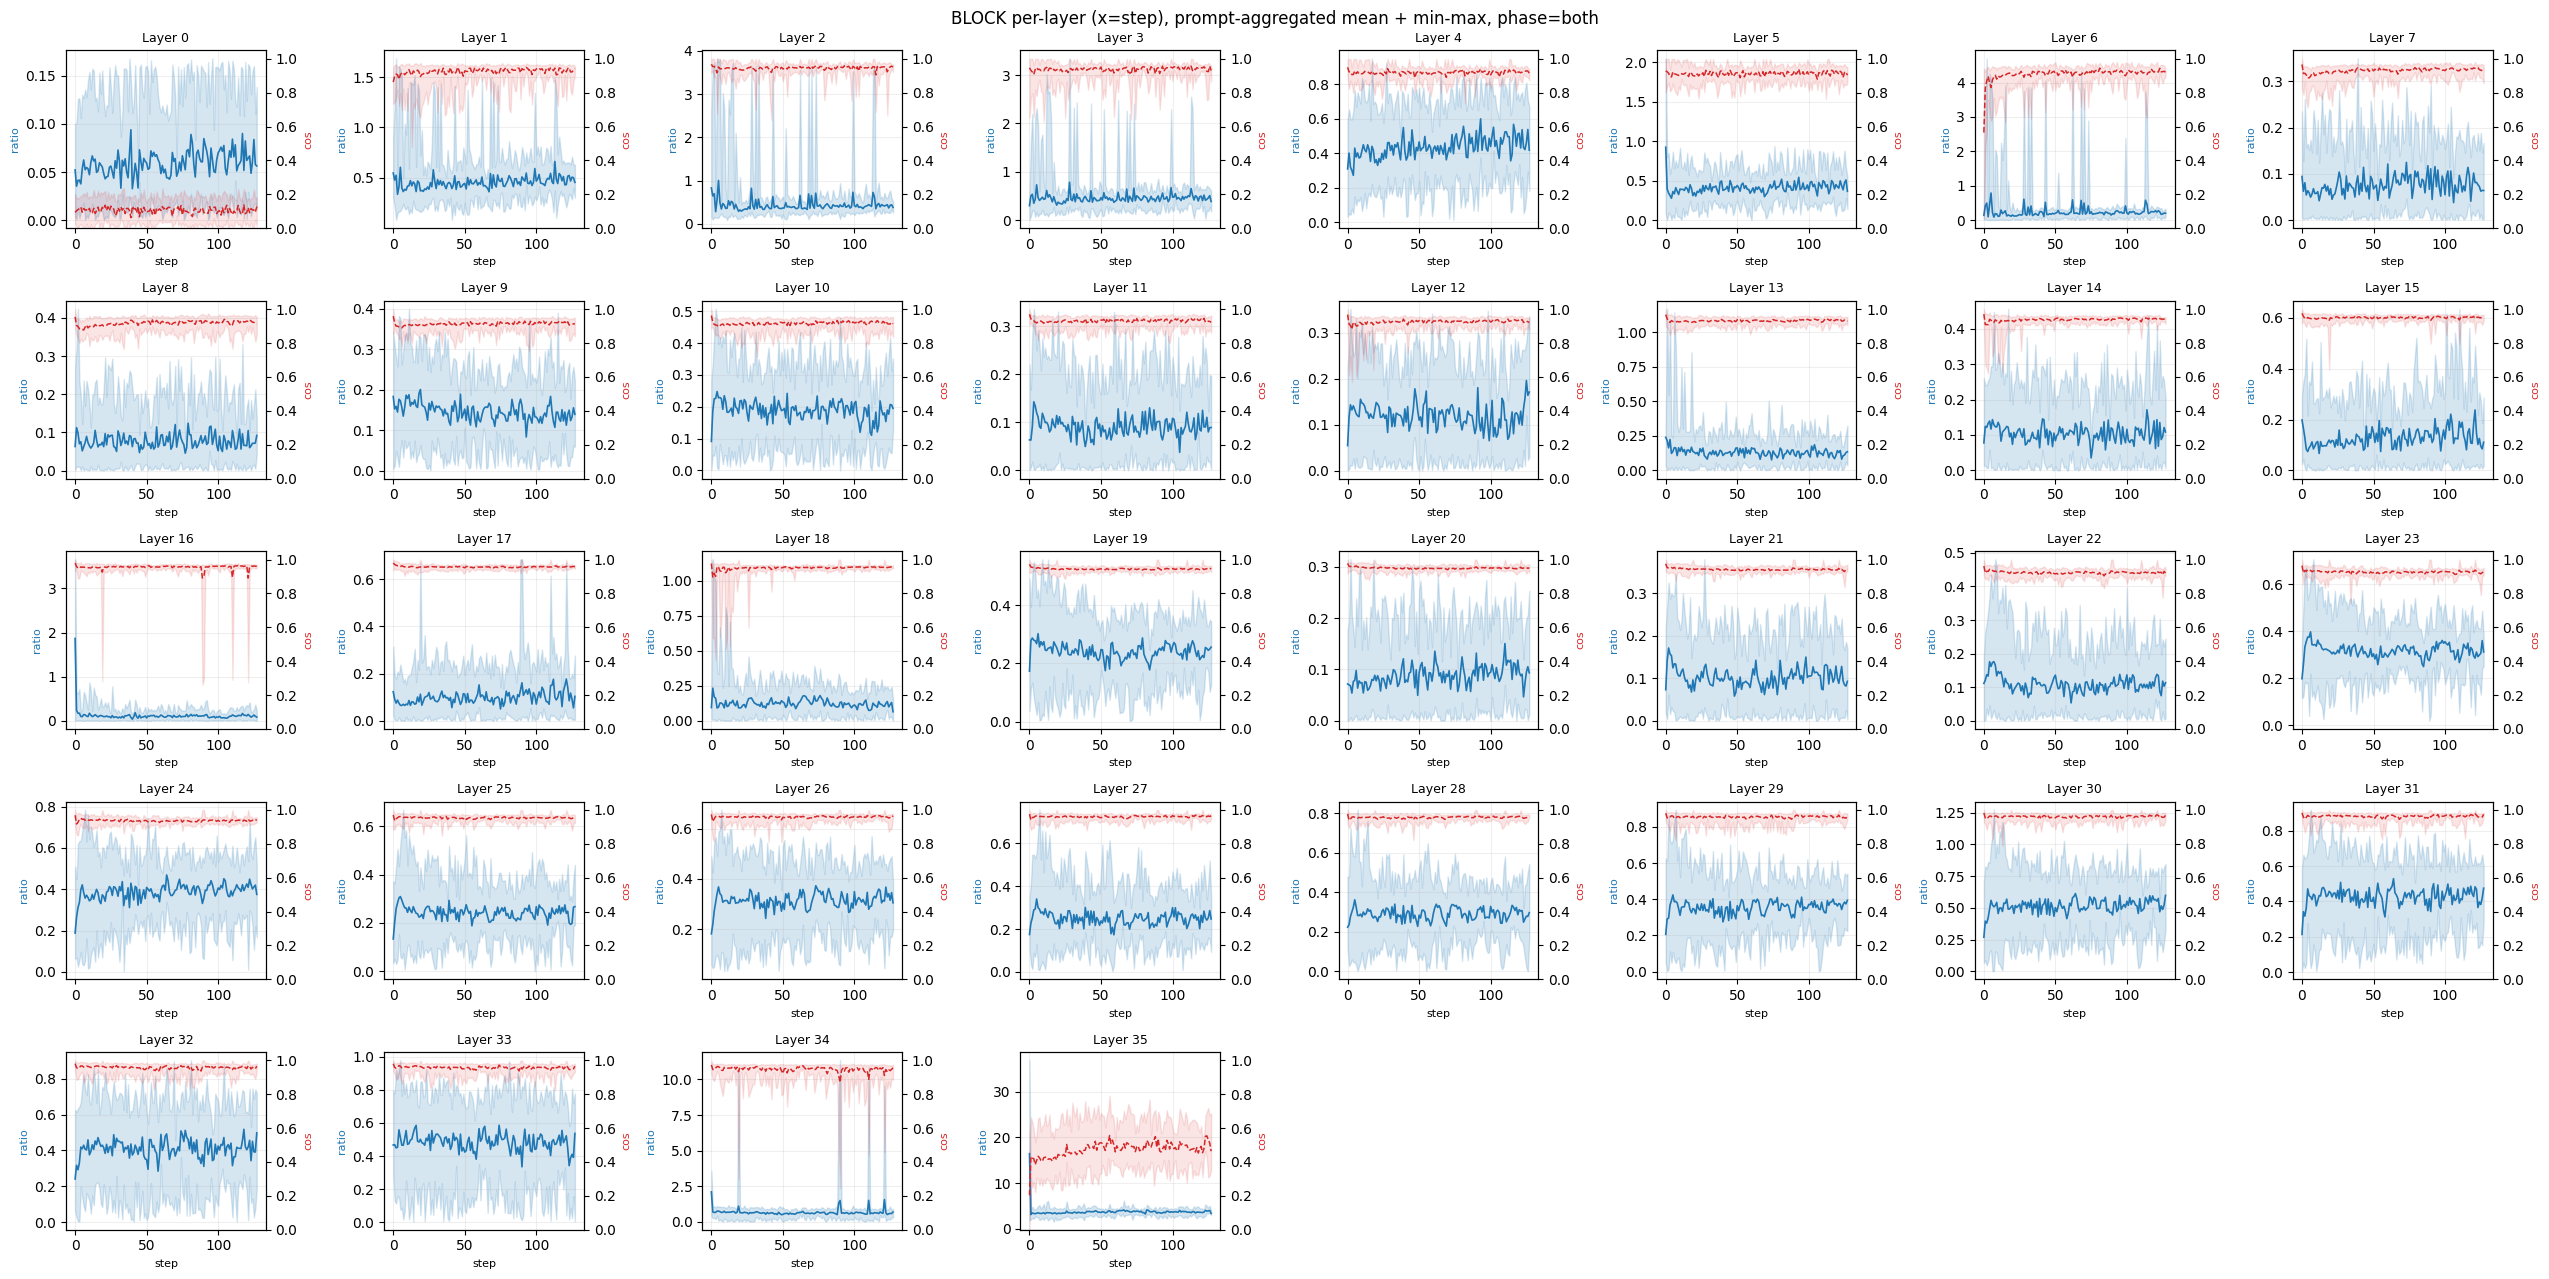

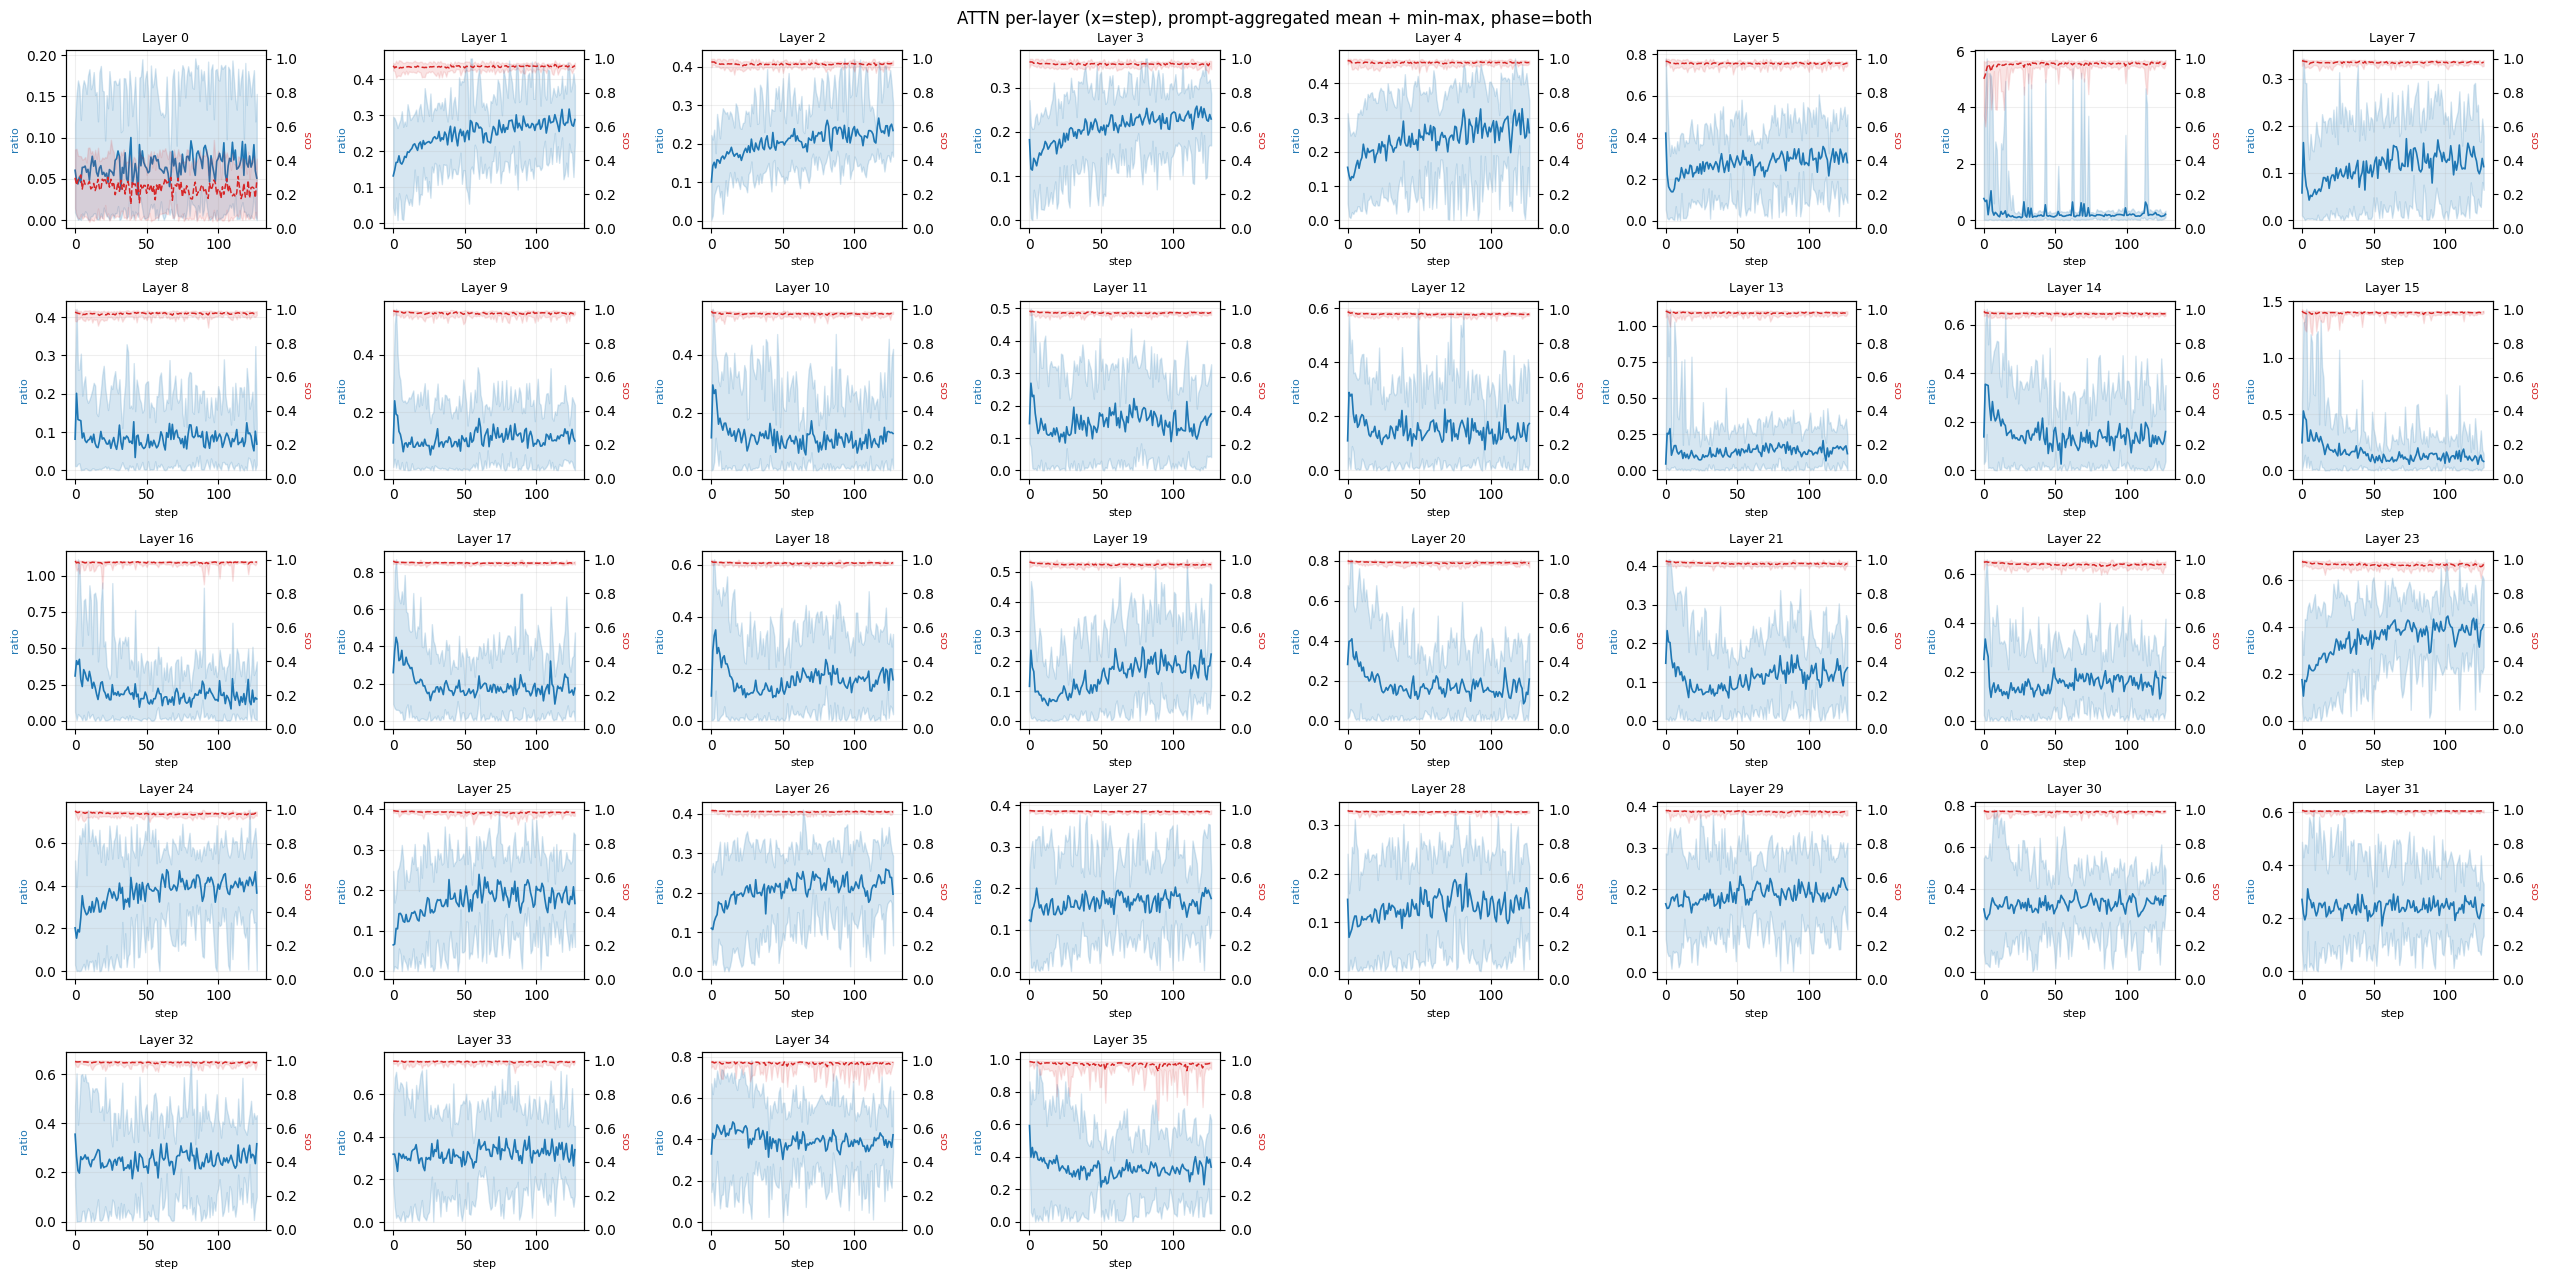

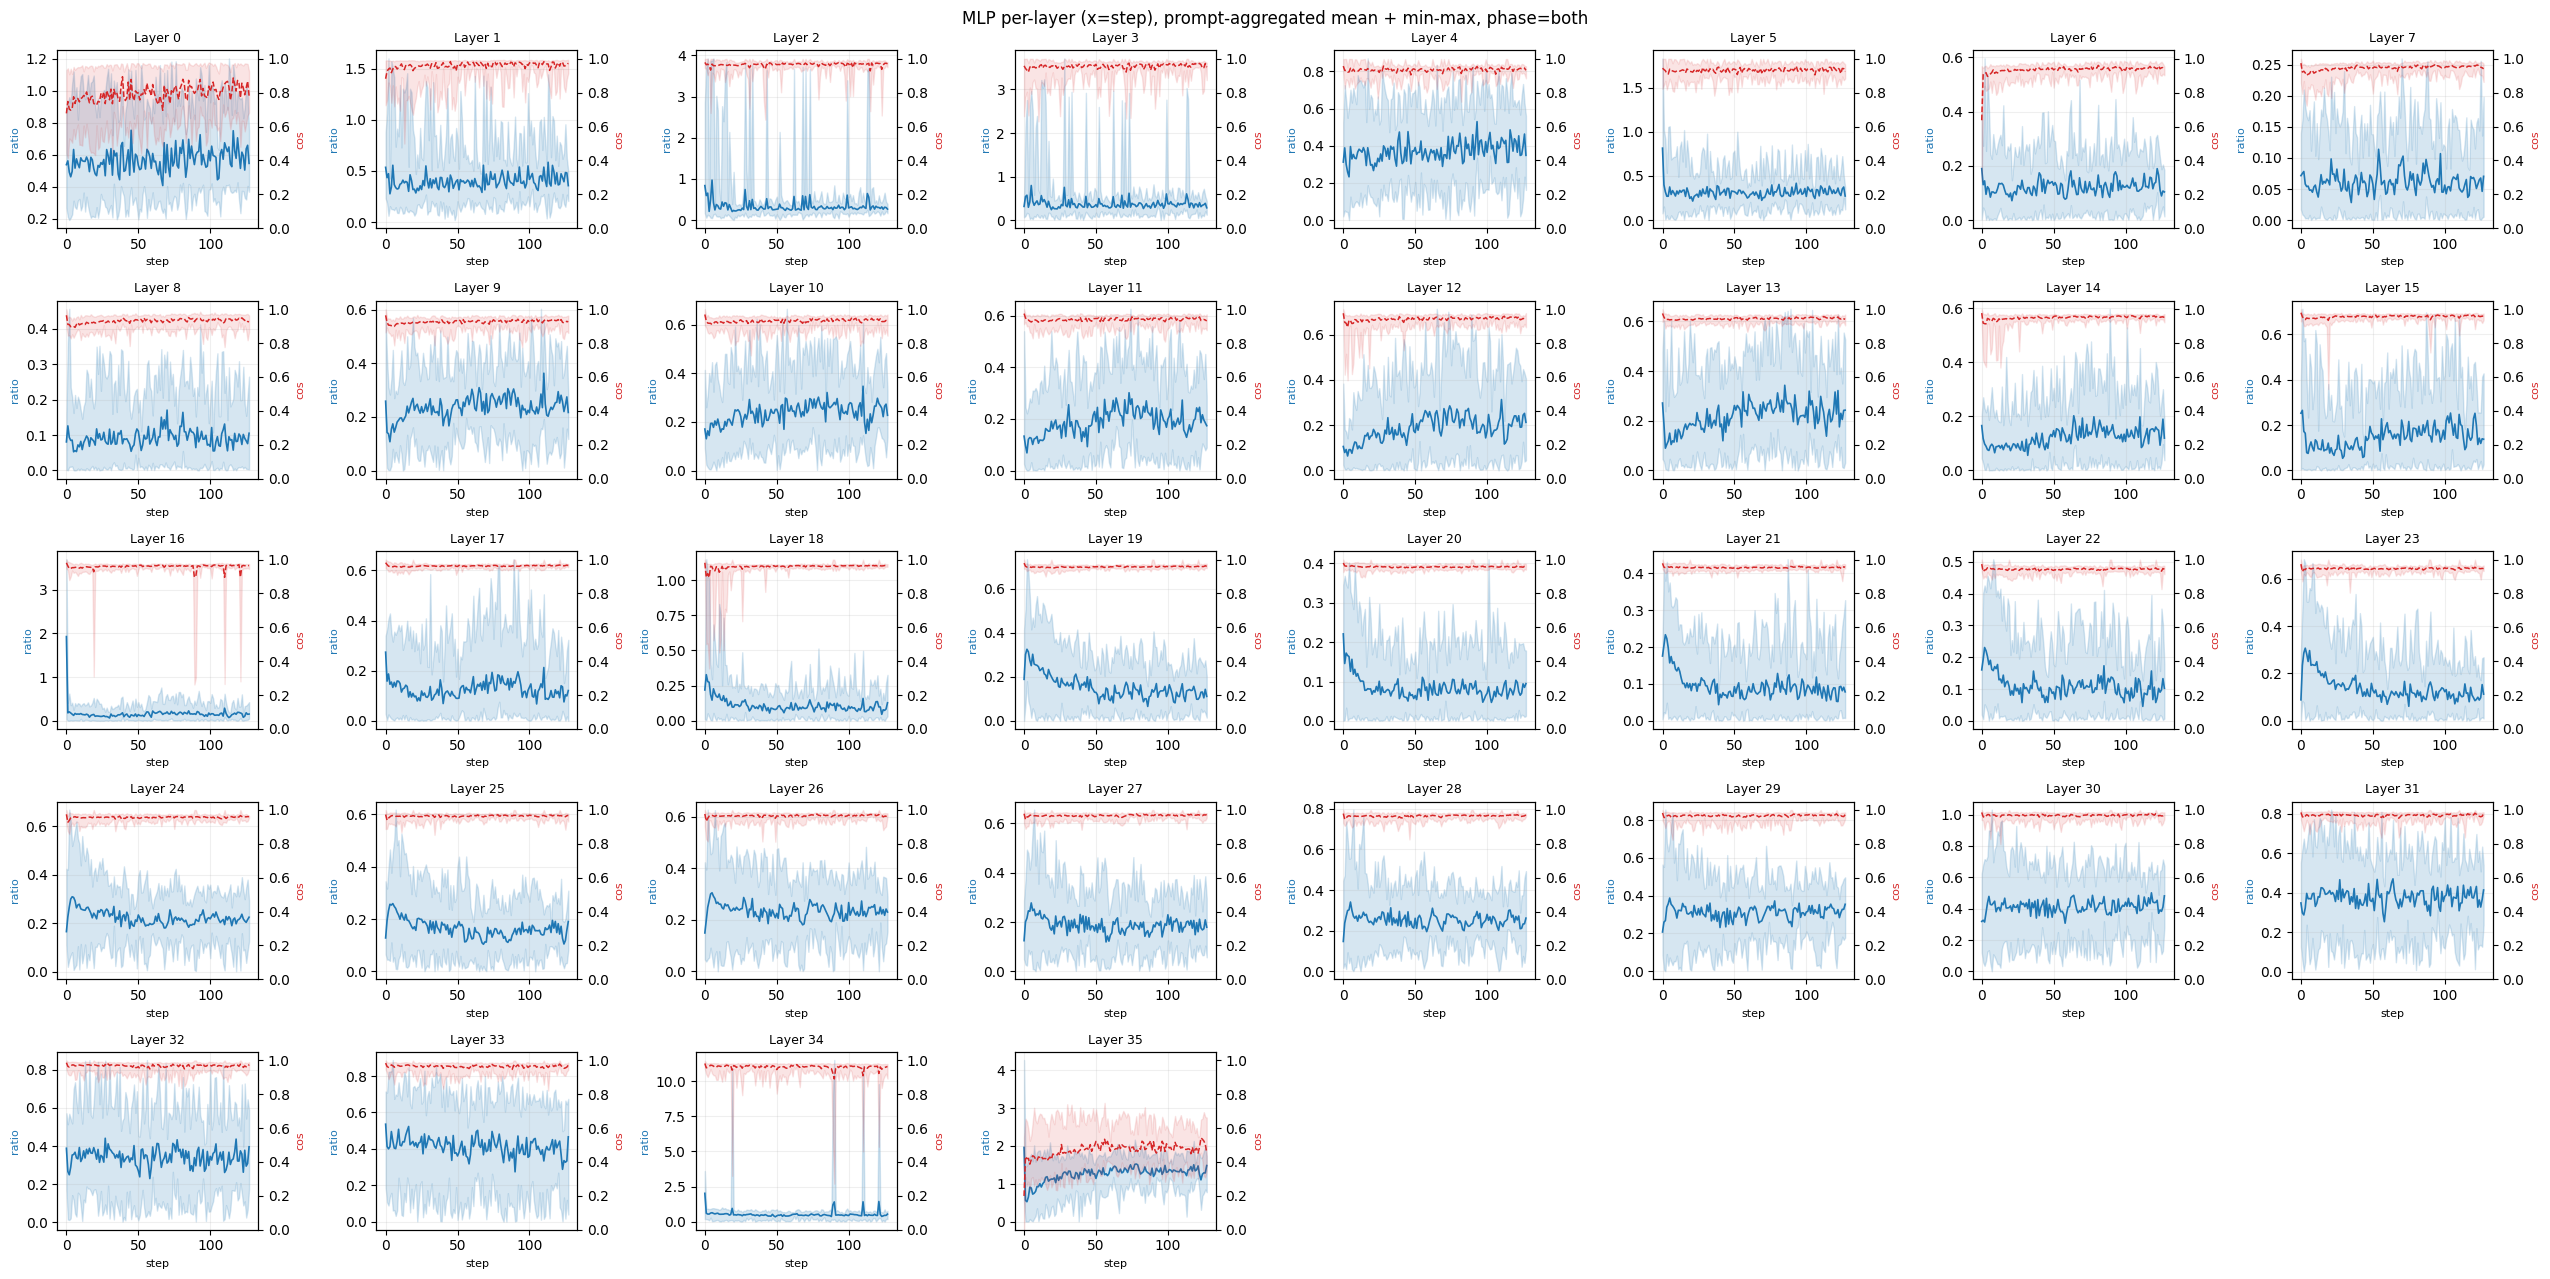

In [2]:
# Prompt-aggregated visualization (self-contained)
from pathlib import Path
import json
import math
import numpy as np
import matplotlib.pyplot as plt

# ---- config ----
# RESULT_PATH = Path('../results/probe.json')
# PHASE = 'prefill'   # 'decode' or 'prefill'
SAVE_PROMPT_AGG_LAYER_GRID = False
OUT_DIR = Path('../results')

# ---- load ----
data = json.loads(RESULT_PATH.read_text(encoding='utf-8'))
runs = data['runs'] if 'runs' in data else [data]
print(f'loaded runs: {len(runs)} from {RESULT_PATH}')


def pick_steps(run, phase='decode'):
    timeline = run.get('timeline') or []
    if timeline:
        picked = [s for s in timeline if s.get('phase') == phase]
        return picked if picked else timeline
    return run.get('steps', [])


def collect_step_layer_values(runs, part='block', metric='para_perp_ratio', phase='decode'):
    # returns: dict[layer][step] -> list(values across prompts)
    out = {}
    for run in runs:
        steps = pick_steps(run, phase=phase)
        for s in steps:
            st = s.get('step')
            if st is None:
                continue

            if part == 'block':
                # Prefer sublayer block_update; fallback to layer_metrics.
                sub_items = s.get('sublayer_metrics') or []
                if sub_items:
                    for it in sub_items:
                        l = it.get('layer')
                        v = (it.get('block_update') or {}).get(metric)
                        if l is None or v is None:
                            continue
                        out.setdefault(int(l), {}).setdefault(int(st), []).append(float(v))
                else:
                    for m in (s.get('layer_metrics') or []):
                        l = m.get('layer')
                        v = m.get(metric)
                        if l is None or v is None:
                            continue
                        out.setdefault(int(l), {}).setdefault(int(st), []).append(float(v))
            else:
                subkey = 'attn_update' if part == 'attn' else 'mlp_update'
                for it in (s.get('sublayer_metrics') or []):
                    l = it.get('layer')
                    v = (it.get(subkey) or {}).get(metric)
                    if l is None or v is None:
                        continue
                    out.setdefault(int(l), {}).setdefault(int(st), []).append(float(v))
    return out


def build_mean_min_max_series(step_map):
    steps = sorted(step_map.keys())
    means = [float(np.mean(step_map[s])) for s in steps]
    mins = [float(np.min(step_map[s])) for s in steps]
    maxs = [float(np.max(step_map[s])) for s in steps]
    return steps, means, mins, maxs


def plot_layer_grid_by_step(runs, part, phase='decode', save_name=None):
    ratio = collect_step_layer_values(runs, part=part, metric='para_perp_ratio', phase=phase)
    cos = collect_step_layer_values(runs, part=part, metric='io_cos_sim', phase=phase)

    layers = sorted(set(ratio.keys()) | set(cos.keys()))
    if not layers:
        print(f'{part}: no data')
        return

    n = len(layers)
    ncols = 8
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for i, l in enumerate(layers):
        ax = axes[i]
        ax2 = ax.twinx()

        if l in ratio and ratio[l]:
            x, m, lo, hi = build_mean_min_max_series(ratio[l])
            m = np.array(m)
            lo = np.array(lo)
            hi = np.array(hi)
            ax.plot(x, m, color='tab:blue', lw=1.2, label='ratio mean')
            ax.fill_between(x, lo, hi, color='tab:blue', alpha=0.18, label='ratio min-max')
        else:
            ax.text(0.5, 0.62, 'No ratio', ha='center', va='center', transform=ax.transAxes, fontsize=8)

        if l in cos and cos[l]:
            x2, m2, lo2, hi2 = build_mean_min_max_series(cos[l])
            m2 = np.array(m2)
            lo2 = np.array(lo2)
            hi2 = np.array(hi2)
            ax2.plot(x2, m2, color='tab:red', lw=1.1, linestyle='--', label='cos mean')
            ax2.fill_between(x2, lo2, hi2, color='tab:red', alpha=0.12, label='cos min-max')
        else:
            ax.text(0.5, 0.43, 'No cos', ha='center', va='center', transform=ax.transAxes, fontsize=8)

        ax.set_title(f'Layer {l}', fontsize=9)
        ax.set_xlabel('step', fontsize=8)
        ax.set_ylabel('ratio', fontsize=8, color='tab:blue')
        # ax.set_ylim(0, 2.05)

        ax2.set_ylabel('cos', fontsize=8, color='tab:red')
        ax2.set_ylim(0, 1.05)
        ax.grid(alpha=0.2)

    for j in range(len(layers), len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{part.upper()} per-layer (x=step), prompt-aggregated mean + min-max, phase={phase}')
    fig.tight_layout()

    if SAVE_PROMPT_AGG_LAYER_GRID and save_name is not None:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out = OUT_DIR / save_name
        fig.savefig(out, dpi=160)
        print('saved:', out)

    plt.show()


plot_layer_grid_by_step(runs, part='block', phase=PHASE, save_name=f'prompt_agg_{PHASE}_block_layergrid_step.png')
plot_layer_grid_by_step(runs, part='attn',  phase=PHASE, save_name=f'prompt_agg_{PHASE}_attn_layergrid_step.png')
plot_layer_grid_by_step(runs, part='mlp',   phase=PHASE, save_name=f'prompt_agg_{PHASE}_mlp_layergrid_step.png')



loaded runs: 12 from /mnt/bn/seed-aws-va/shwai.he/demystifying-transformers-main/results/generation_logits/Qwen3-4B-Instruct-2507-modeboth-tokens128.json


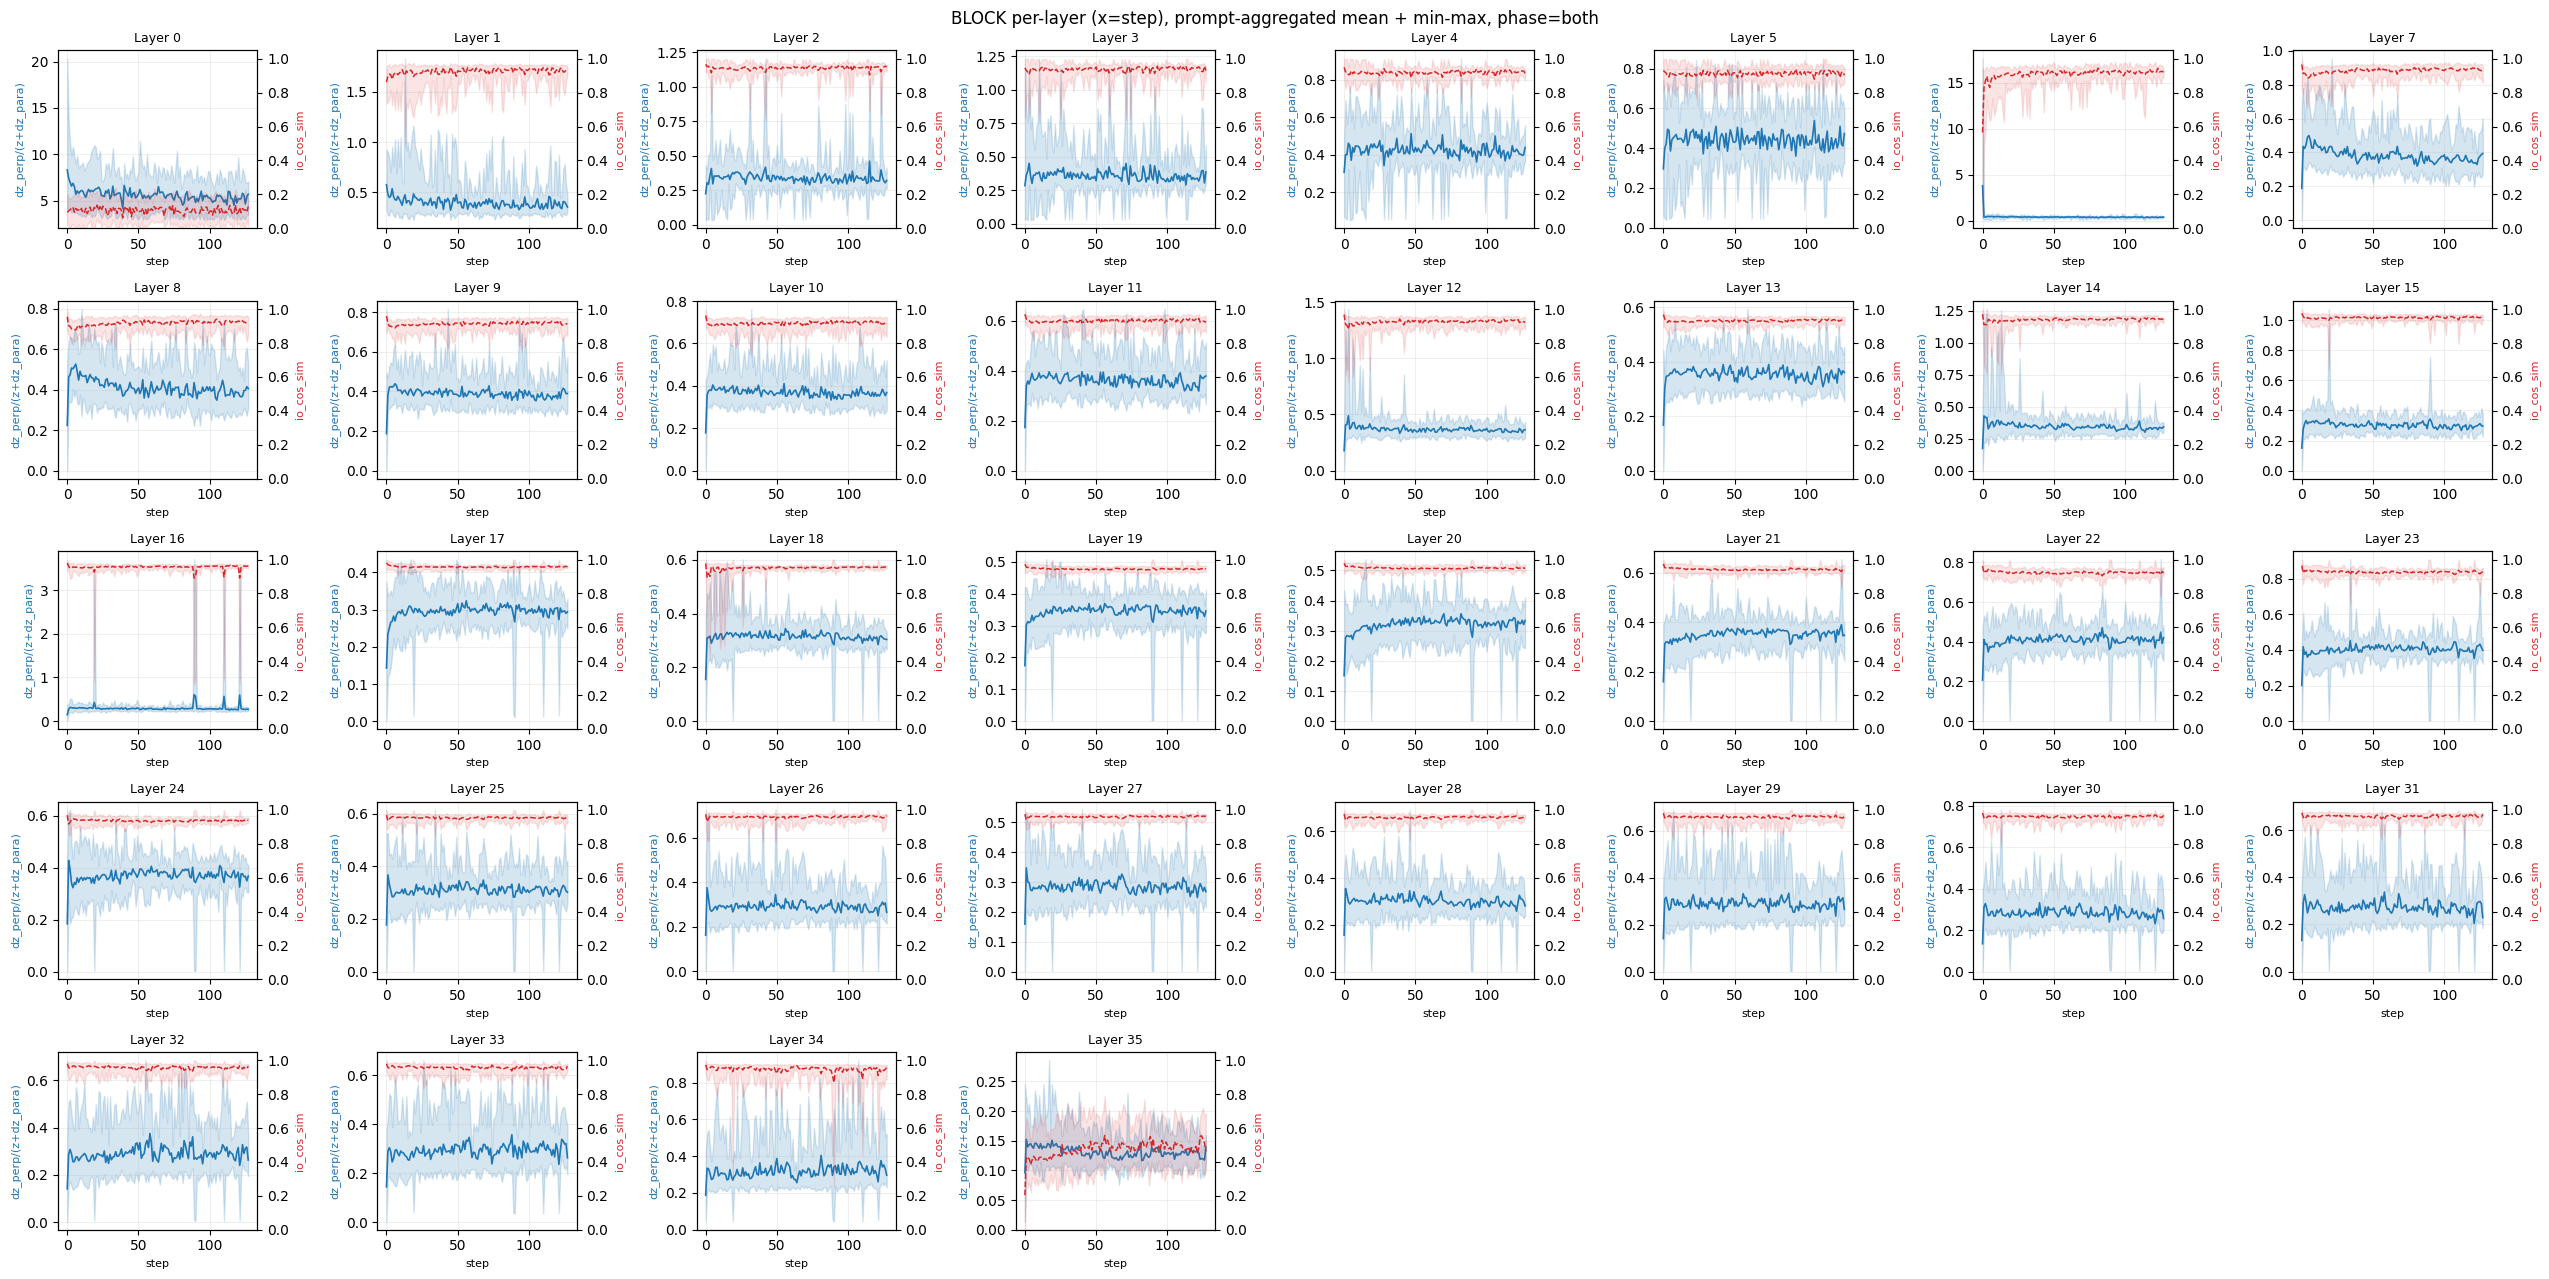

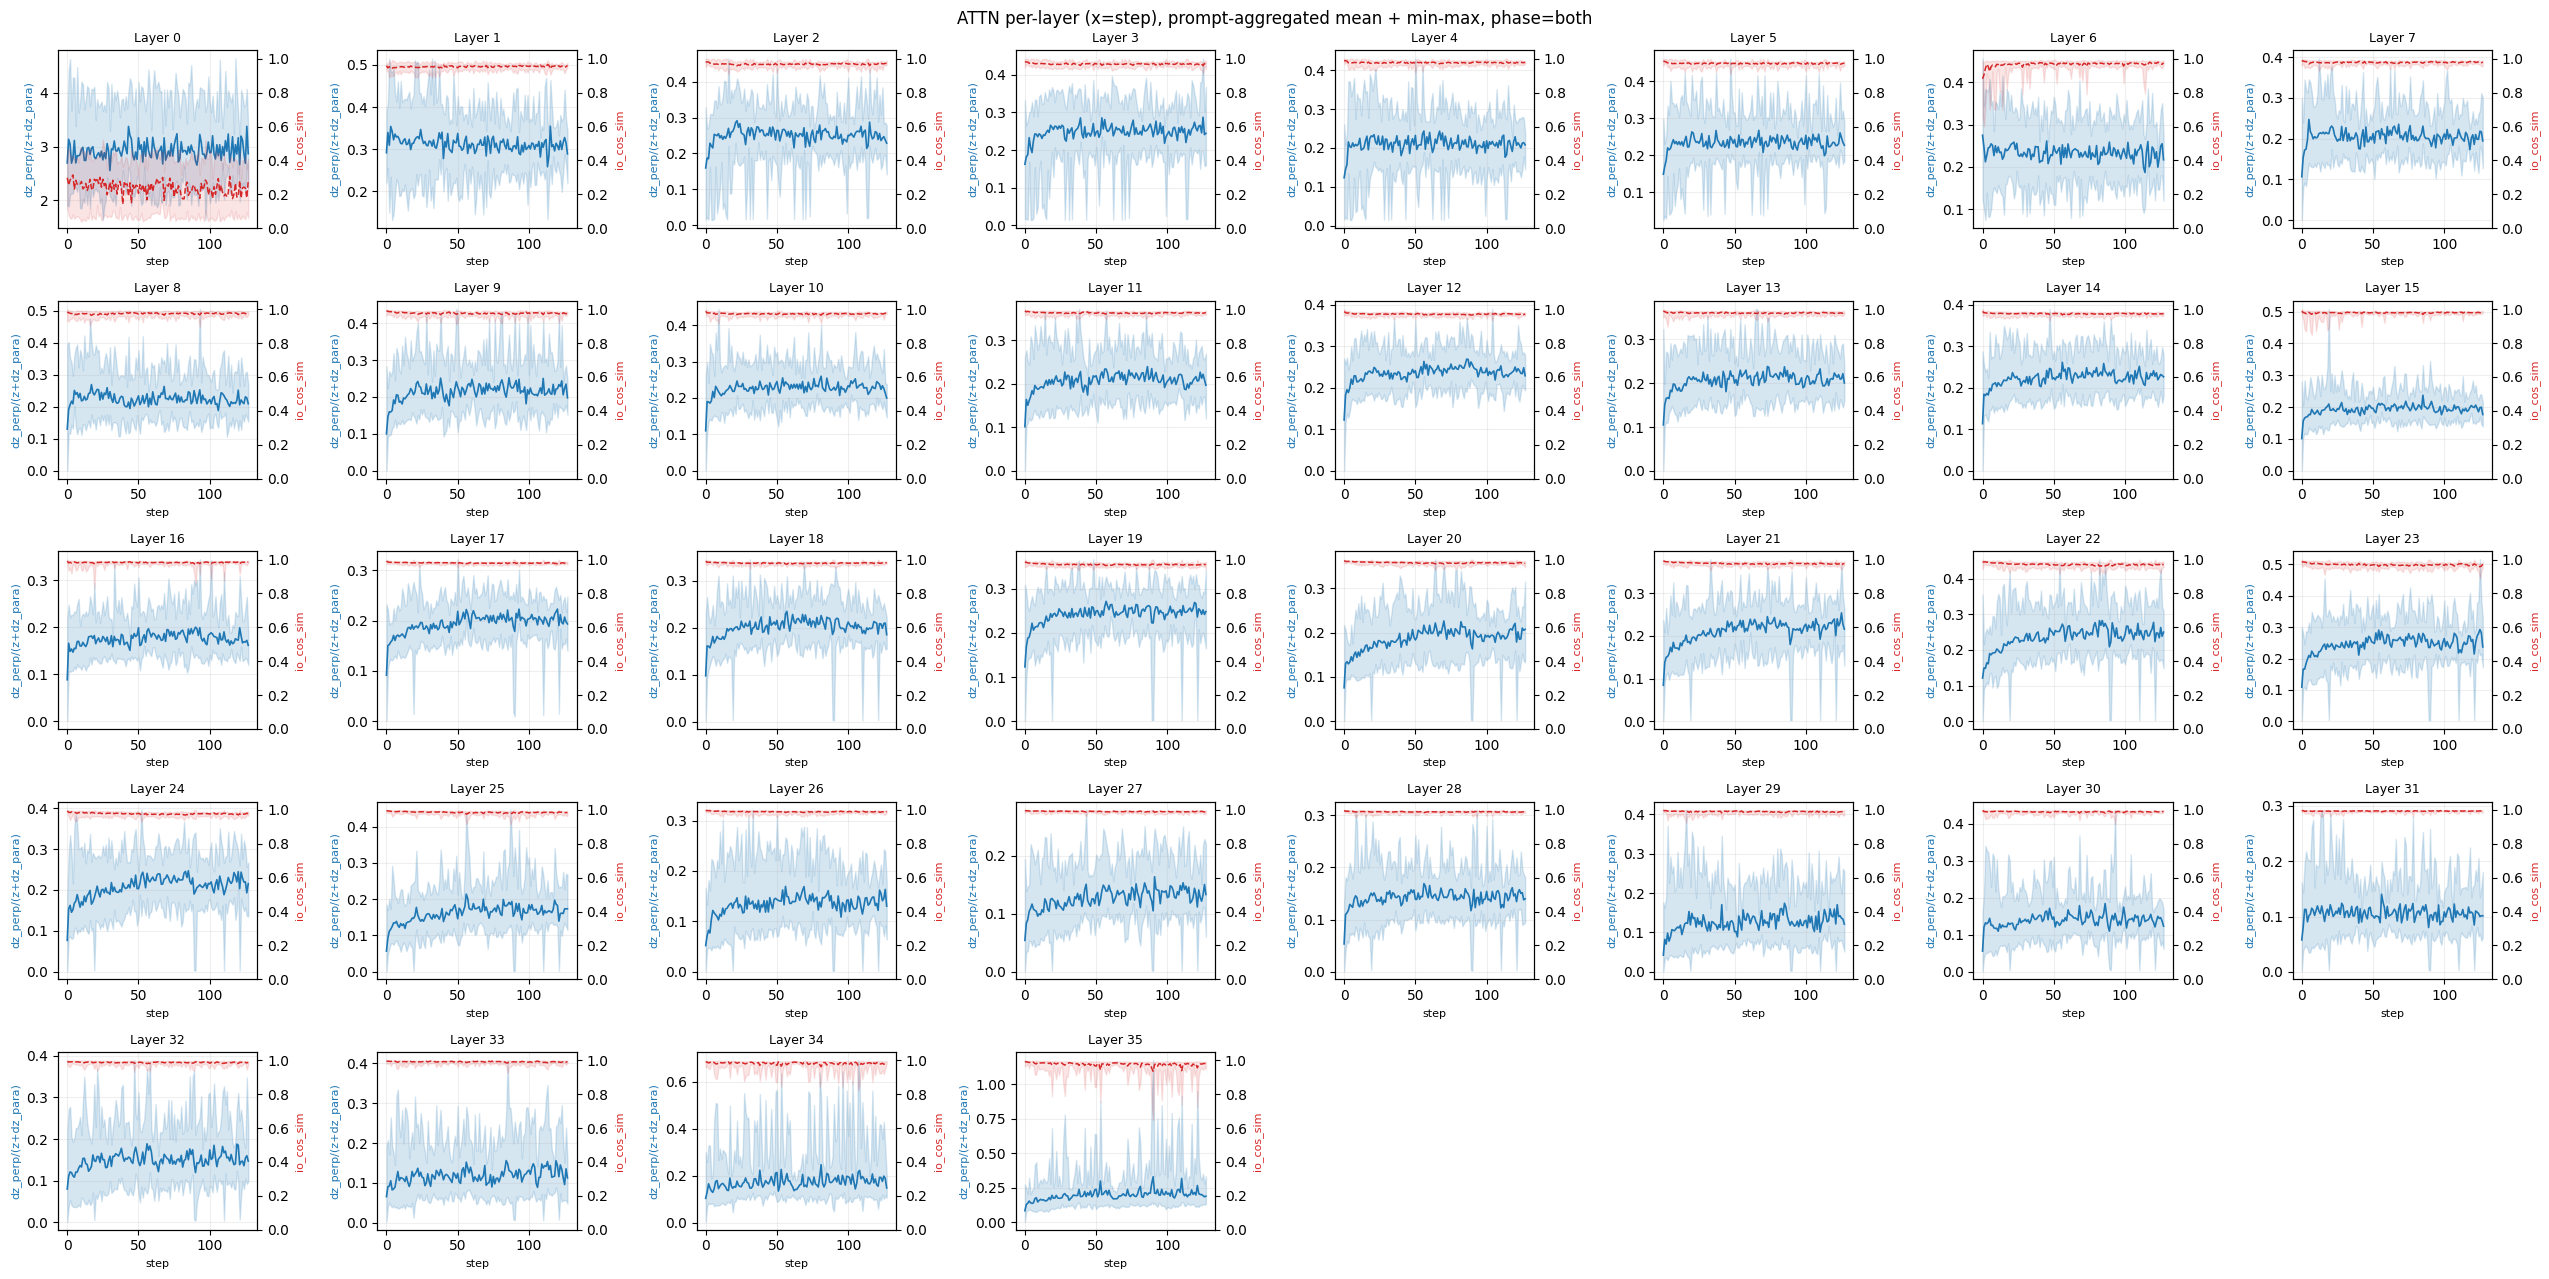

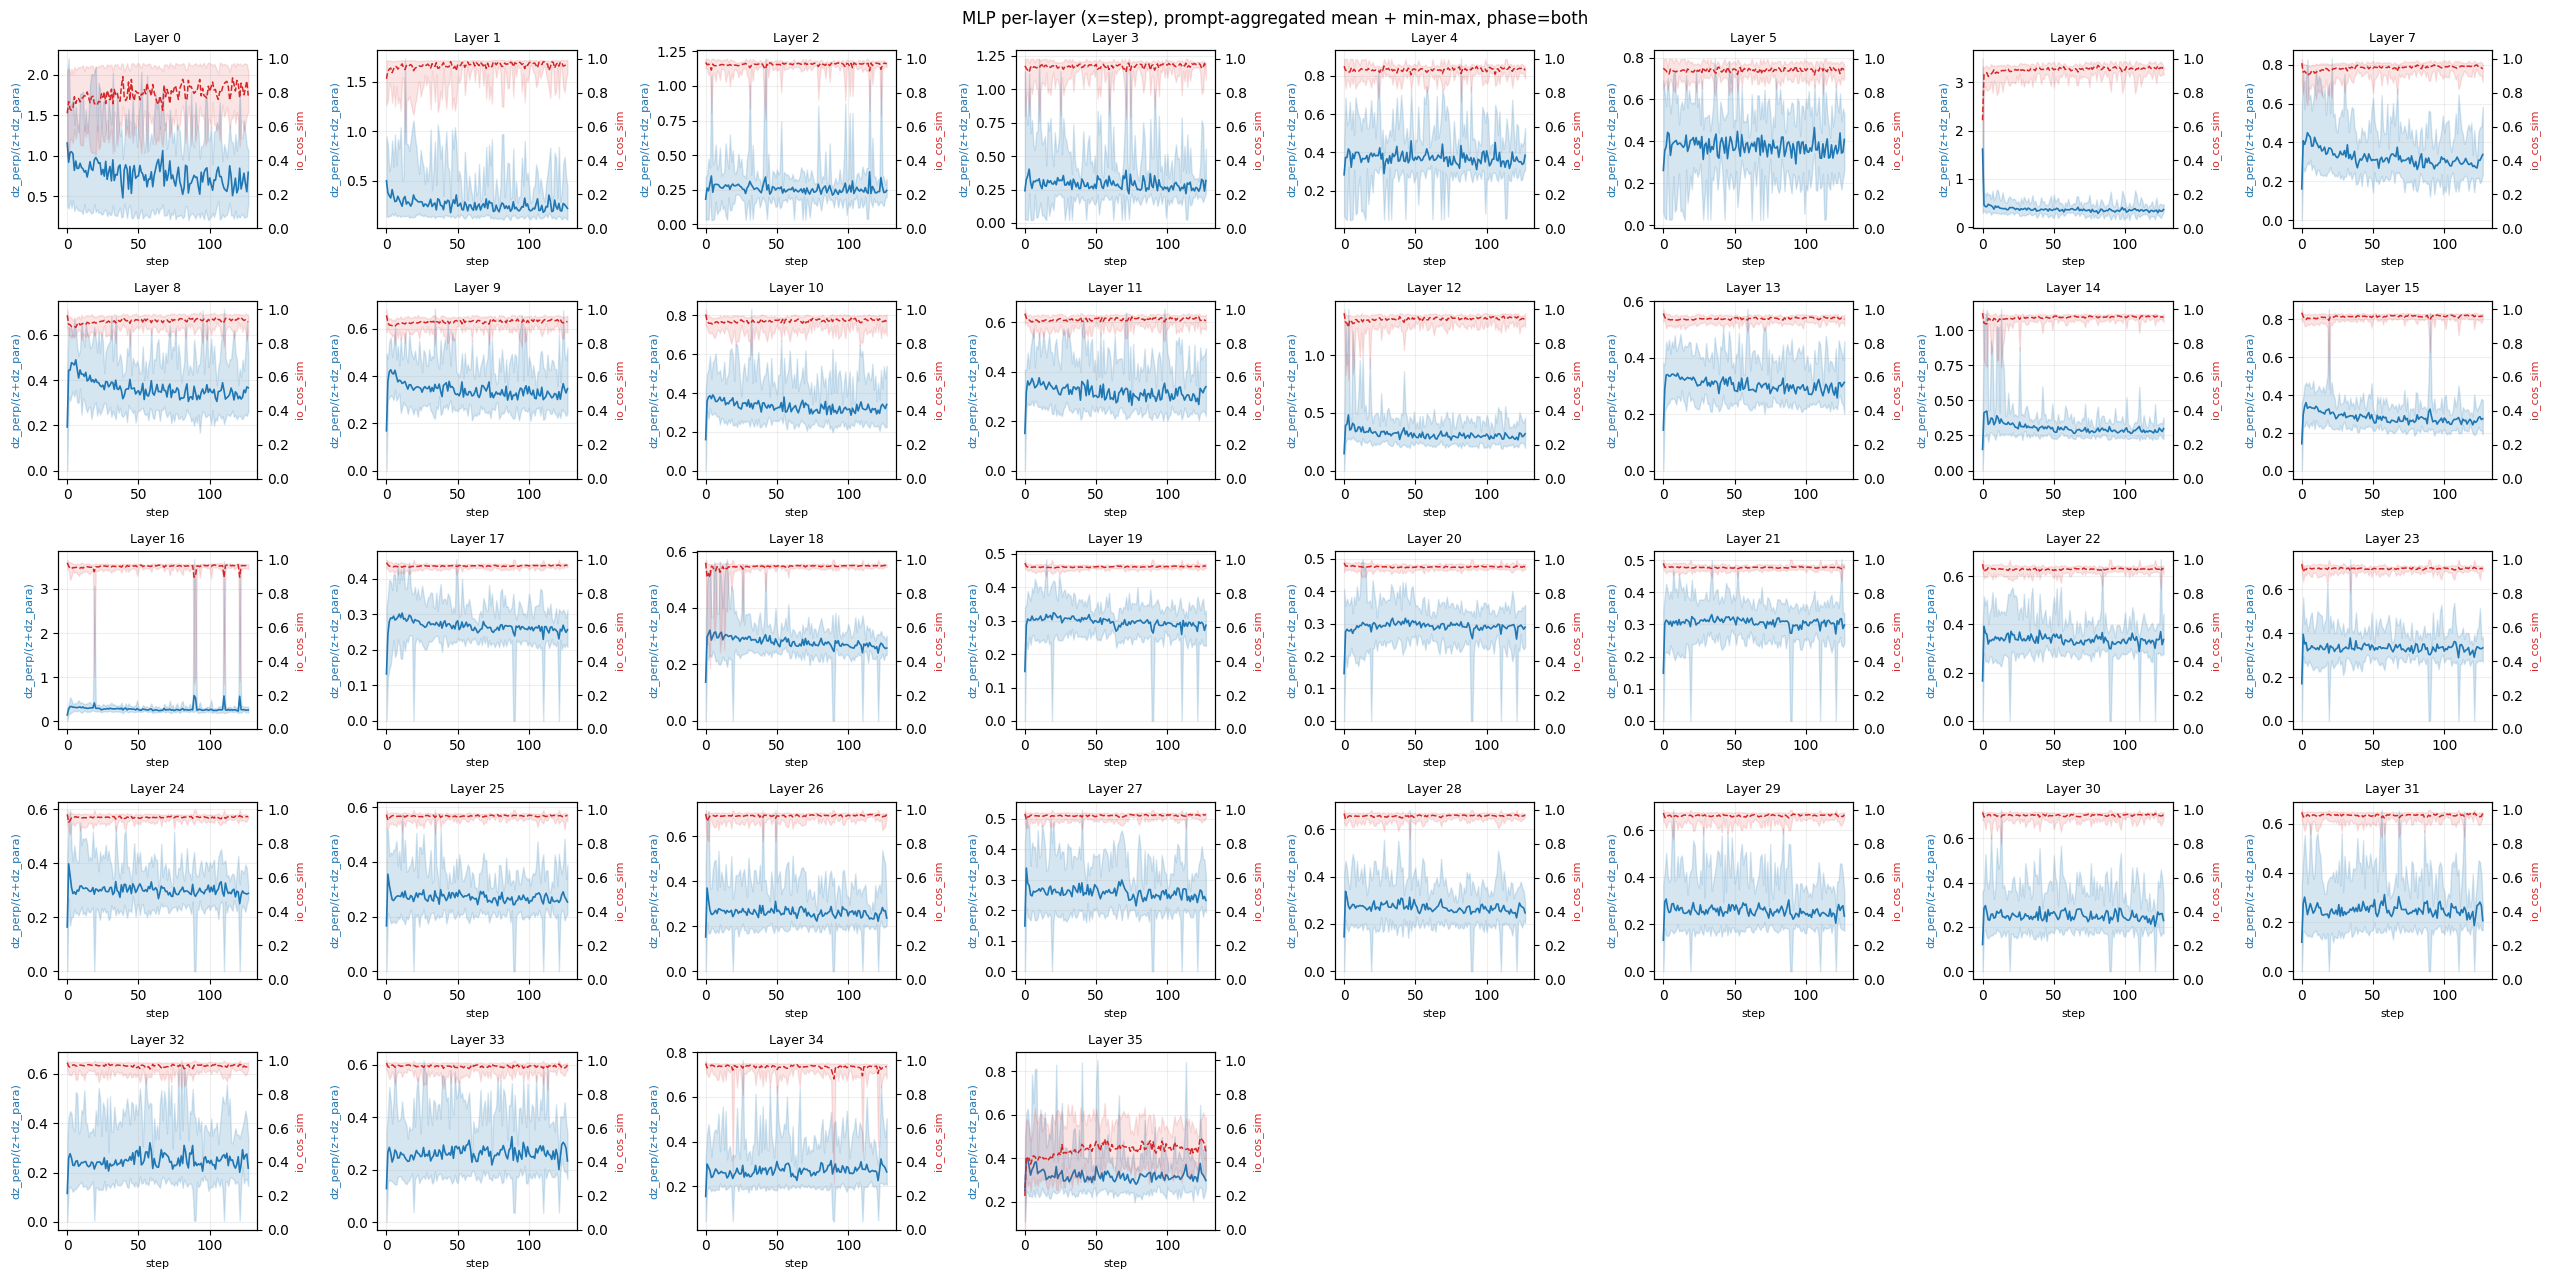

In [3]:
# Prompt-aggregated visualization (self-contained)
from pathlib import Path
import json
import math
import numpy as np
import matplotlib.pyplot as plt

# ---- config ----
# RESULT_PATH = Path('../results/probe.json')
# PHASE = 'prefill'   # 'decode' or 'prefill'
SAVE_PROMPT_AGG_LAYER_GRID = False
OUT_DIR = Path('../results')

# left-axis metric: 'dz_perp_over_z_plus_dz_para' or 'para_perp_ratio'
LEFT_METRIC = 'dz_perp_over_z_plus_dz_para'
LEFT_LABEL = 'dz_perp/(z+dz_para)' if LEFT_METRIC == 'dz_perp_over_z_plus_dz_para' else 'para_perp_ratio'

# optional layer trimming
TRIM_EDGE_LAYERS = False  # True -> drop first/last layer
# -----------------

# ---- load ----
data = json.loads(RESULT_PATH.read_text(encoding='utf-8'))
runs = data['runs'] if 'runs' in data else [data]
print(f'loaded runs: {len(runs)} from {RESULT_PATH}')


def pick_steps(run, phase='decode'):
    # new format
    timeline = run.get('timeline') or []
    if timeline:
        picked = [s for s in timeline if s.get('phase') == phase]
        return picked if picked else timeline

    # fallback for mixed outputs
    if phase == 'prefill':
        prefill = run.get('prefill_steps') or []
        if prefill:
            return prefill
    return run.get('steps', [])


def collect_step_layer_values(runs, part='block', metric='para_perp_ratio', phase='decode'):
    # returns: dict[layer][step] -> list(values across prompts)
    out = {}
    for run in runs:
        steps = pick_steps(run, phase=phase)
        for s in steps:
            st = s.get('step')
            if st is None:
                continue

            if part == 'block':
                # Prefer sublayer block_update; fallback to layer_metrics.
                sub_items = s.get('sublayer_metrics') or []
                if sub_items:
                    for it in sub_items:
                        l = it.get('layer')
                        v = (it.get('block_update') or {}).get(metric)
                        if l is None or v is None:
                            continue
                        out.setdefault(int(l), {}).setdefault(int(st), []).append(float(v))
                else:
                    for m in (s.get('layer_metrics') or []):
                        l = m.get('layer')
                        v = m.get(metric)
                        if l is None or v is None:
                            continue
                        out.setdefault(int(l), {}).setdefault(int(st), []).append(float(v))
            else:
                subkey = 'attn_update' if part == 'attn' else 'mlp_update'
                for it in (s.get('sublayer_metrics') or []):
                    l = it.get('layer')
                    v = (it.get(subkey) or {}).get(metric)
                    if l is None or v is None:
                        continue
                    out.setdefault(int(l), {}).setdefault(int(st), []).append(float(v))
    return out


def build_mean_min_max_series(step_map):
    steps = sorted(step_map.keys())
    means = [float(np.mean(step_map[s])) for s in steps]
    mins = [float(np.min(step_map[s])) for s in steps]
    maxs = [float(np.max(step_map[s])) for s in steps]
    return steps, means, mins, maxs


def plot_layer_grid_by_step(runs, part, phase='decode', save_name=None):
    left = collect_step_layer_values(runs, part=part, metric=LEFT_METRIC, phase=phase)
    cos = collect_step_layer_values(runs, part=part, metric='io_cos_sim', phase=phase)

    layers = sorted(set(left.keys()) | set(cos.keys()))
    if TRIM_EDGE_LAYERS and len(layers) > 2:
        layers = layers[1:-1]

    if not layers:
        print(f'{part}: no data')
        return

    n = len(layers)
    ncols = 8
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for i, l in enumerate(layers):
        ax = axes[i]
        ax2 = ax.twinx()

        if l in left and left[l]:
            x, m, lo, hi = build_mean_min_max_series(left[l])
            m, lo, hi = np.array(m), np.array(lo), np.array(hi)
            ax.plot(x, m, color='tab:blue', lw=1.2, label=f'{LEFT_LABEL} mean')
            ax.fill_between(x, lo, hi, color='tab:blue', alpha=0.18, label=f'{LEFT_LABEL} min-max')
        else:
            ax.text(0.5, 0.62, f'No {LEFT_LABEL}', ha='center', va='center', transform=ax.transAxes, fontsize=8)

        if l in cos and cos[l]:
            x2, m2, lo2, hi2 = build_mean_min_max_series(cos[l])
            m2, lo2, hi2 = np.array(m2), np.array(lo2), np.array(hi2)
            ax2.plot(x2, m2, color='tab:red', lw=1.1, linestyle='--', label='cos mean')
            ax2.fill_between(x2, lo2, hi2, color='tab:red', alpha=0.12, label='cos min-max')
        else:
            ax.text(0.5, 0.43, 'No cos', ha='center', va='center', transform=ax.transAxes, fontsize=8)

        ax.set_title(f'Layer {l}', fontsize=9)
        ax.set_xlabel('step', fontsize=8)
        ax.set_ylabel(LEFT_LABEL, fontsize=8, color='tab:blue')
        ax2.set_ylabel('io_cos_sim', fontsize=8, color='tab:red')
        ax2.set_ylim(0, 1.05)
        ax.grid(alpha=0.2)

    for j in range(len(layers), len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{part.upper()} per-layer (x=step), prompt-aggregated mean + min-max, phase={phase}')
    fig.tight_layout()

    if SAVE_PROMPT_AGG_LAYER_GRID and save_name is not None:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out = OUT_DIR / save_name
        fig.savefig(out, dpi=160)
        print('saved:', out)

    plt.show()


plot_layer_grid_by_step(runs, part='block', phase=PHASE, save_name=f'prompt_agg_{PHASE}_block_layergrid_step.png')
plot_layer_grid_by_step(runs, part='attn',  phase=PHASE, save_name=f'prompt_agg_{PHASE}_attn_layergrid_step.png')
plot_layer_grid_by_step(runs, part='mlp',   phase=PHASE, save_name=f'prompt_agg_{PHASE}_mlp_layergrid_step.png')


loaded runs: 12 from /mnt/bn/seed-aws-va/shwai.he/demystifying-transformers-main/results/generation_logits/Qwen3-4B-Instruct-2507-modeboth-tokens128.json
prompt 0: steps=171, phase=both, has_sublayer=True, has_layer=False


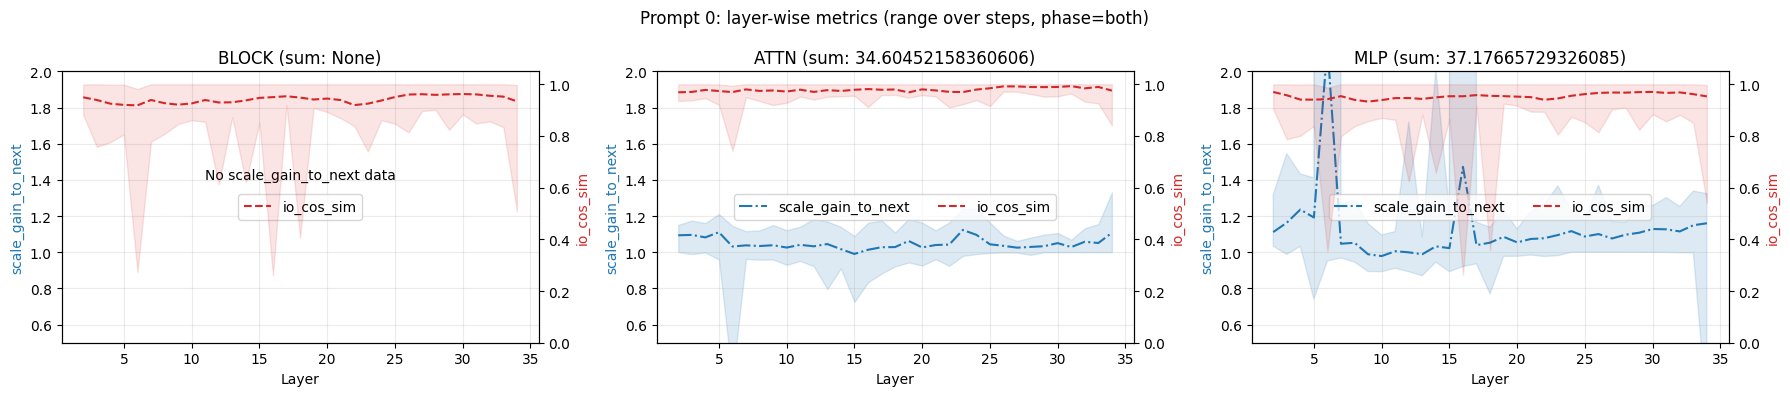

In [7]:
# NEW BLOCK: per-prompt plots, x-axis=layer, range over steps (min-max)
from pathlib import Path
import json
import matplotlib.pyplot as plt

# ---- config ----
# RESULT_PATH = Path('../results/generation_probe.json')
# PHASE = 'decode'   # 'decode' or 'prefill'
SAVE_FIG = False
# OUT_DIR = Path('../results')
LEFT_METRIC = 'scale_gain_to_next'  # or 'para_perp_ratio'
LEFT_LABEL = 'scale_gain_to_next' if LEFT_METRIC == 'scale_gain_to_next' else 'para_perp_ratio'
TRIM_EDGE_LAYERS = False
TRIM_EDGE_LAYERS = True

start_layer = 2

# -----------------

data = json.loads(RESULT_PATH.read_text(encoding='utf-8'))
runs = data['runs'] if 'runs' in data else [data]
print(f'loaded runs: {len(runs)} from {RESULT_PATH}')


def pick_steps(run, phase='decode'):
    timeline = run.get('timeline') or []
    if timeline:
        picked = [s for s in timeline if s.get('phase') == phase]
        return picked if picked else timeline
    if phase == 'prefill':
        prefill = run.get('prefill_steps') or []
        if prefill:
            return prefill
    return run.get('steps', [])


def collect_layerwise_from_layer_metrics(steps, value_key):
    by_layer = {}
    for s in steps:
        for m in (s.get('layer_metrics') or []):
            l = m.get('layer')
            v = m.get(value_key)
            if l is None or v is None:
                continue
            by_layer.setdefault(int(l), []).append(float(v))
    layers = sorted(by_layer)
    if TRIM_EDGE_LAYERS and len(layers) > 2:
        layers = layers[start_layer:-1]
    means = [sum(by_layer[l]) / len(by_layer[l]) for l in layers]
    mins = [min(by_layer[l]) for l in layers]
    maxs = [max(by_layer[l]) for l in layers]
    return layers, means, mins, maxs


def collect_layerwise_from_sublayer(steps, metric_key, value_key):
    by_layer = {}
    for s in steps:
        for item in (s.get('sublayer_metrics') or []):
            l = item.get('layer')
            v = (item.get(metric_key) or {}).get(value_key)
            if l is None or v is None:
                continue
            by_layer.setdefault(int(l), []).append(float(v))
    layers = sorted(by_layer)
    if TRIM_EDGE_LAYERS and len(layers) > 2:
        layers = layers[start_layer:-1]
    means = [sum(by_layer[l]) / len(by_layer[l]) for l in layers]
    mins = [min(by_layer[l]) for l in layers]
    maxs = [max(by_layer[l]) for l in layers]
    return layers, means, mins, maxs


series = [('block', 'BLOCK', 'block_update'), ('attn', 'ATTN', 'attn_update'), ('mlp', 'MLP', 'mlp_update')]

for prompt_idx, run in enumerate(runs):
    steps = pick_steps(run, phase=PHASE)
    if not steps:
        print(f'prompt {prompt_idx}: no steps ({PHASE}), skipped')
        continue

    has_sublayer = any(('sublayer_metrics' in s and s['sublayer_metrics']) for s in steps)
    has_layer = any(('layer_metrics' in s and s['layer_metrics']) for s in steps)
    print(f'prompt {prompt_idx}: steps={len(steps)}, phase={PHASE}, has_sublayer={has_sublayer}, has_layer={has_layer}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=False)

    for ax, (name, title, metric_key) in zip(axes, series):
        used_layer_left_fallback = False
        used_layer_cos_fallback = False

        if has_sublayer:
            if name == 'block':
                # block: prefer block_update in sublayer metrics
                x_l, mean_l, min_l, max_l = collect_layerwise_from_sublayer(steps, 'block_update', LEFT_METRIC)
                x_c, mean_c, min_c, max_c = collect_layerwise_from_sublayer(steps, 'block_update', 'io_cos_sim')
                if has_layer and not x_l:
                    x_l, mean_l, min_l, max_l = collect_layerwise_from_layer_metrics(steps, LEFT_METRIC)
                    used_layer_left_fallback = True
                if has_layer and not x_c:
                    x_c, mean_c, min_c, max_c = collect_layerwise_from_layer_metrics(steps, 'io_cos_sim')
                    used_layer_cos_fallback = True
            else:
                x_l, mean_l, min_l, max_l = collect_layerwise_from_sublayer(steps, metric_key, LEFT_METRIC)
                x_c, mean_c, min_c, max_c = collect_layerwise_from_sublayer(steps, metric_key, 'io_cos_sim')
        else:
            x_l, mean_l, min_l, max_l = collect_layerwise_from_layer_metrics(steps, LEFT_METRIC)
            x_c, mean_c, min_c, max_c = collect_layerwise_from_layer_metrics(steps, 'io_cos_sim')

        if x_l:
            ax.plot(x_l, mean_l, color='tab:blue', linestyle='-.', label=f'{LEFT_LABEL}')
            ax.fill_between(x_l, min_l, max_l, color='tab:blue', alpha=0.15, label='_nolegend_')
        else:
            ax.text(0.5, 0.62, f'No {LEFT_LABEL} data', ha='center', va='center', transform=ax.transAxes)

        ax2 = ax.twinx()
        if x_c:
            ax2.plot(x_c, mean_c, color='tab:red', linestyle='--', label='io_cos_sim')
            ax2.fill_between(x_c, min_c, max_c, color='tab:red', alpha=0.12, label='_nolegend_')
        else:
            ax.text(0.5, 0.42, 'No cos data', ha='center', va='center', transform=ax.transAxes)

        sum_left = float(np.nansum(mean_l)) if len(mean_l) > 0 else None

        ax.set_title(f'{title} (sum: {sum_left})')
        ax.set_xlabel('Layer')
        ax.set_ylabel(LEFT_LABEL, color='tab:blue')
        ax.grid(alpha=0.25)
        ax.set_ylim(0.5, 2)

        ax2.set_ylabel('io_cos_sim', color='tab:red')
        ax2.set_ylim(0, 1.05)

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        if lines1 or lines2:
            ax.legend(lines1 + lines2, labels1 + labels2, ncol=2, loc='center')

        if used_layer_left_fallback:
            ax.text(0.01, 0.02, f'{LEFT_LABEL} from layer_metrics', transform=ax.transAxes, fontsize=8, color='tab:blue')
        if used_layer_cos_fallback:
            ax.text(0.01, 0.08, 'cos from layer_metrics', transform=ax.transAxes, fontsize=8, color='tab:red')

    fig.suptitle(f'Prompt {prompt_idx}: layer-wise metrics (range over steps, phase={PHASE})')
    fig.tight_layout()

    if SAVE_FIG:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out_path = OUT_DIR / f'prompt{prompt_idx}_{PHASE}_layerwise_range.png'
        fig.savefig(out_path, dpi=150)
        print(f'saved: {out_path}')

    plt.show()
    break


loaded runs: 12 from /mnt/bn/seed-aws-va/shwai.he/demystifying-transformers-main/results/generation_logits/Qwen3-4B-Instruct-2507-modeboth-tokens128.json
prompt 0: steps=171, phase=both, has_sublayer=True, has_layer=False


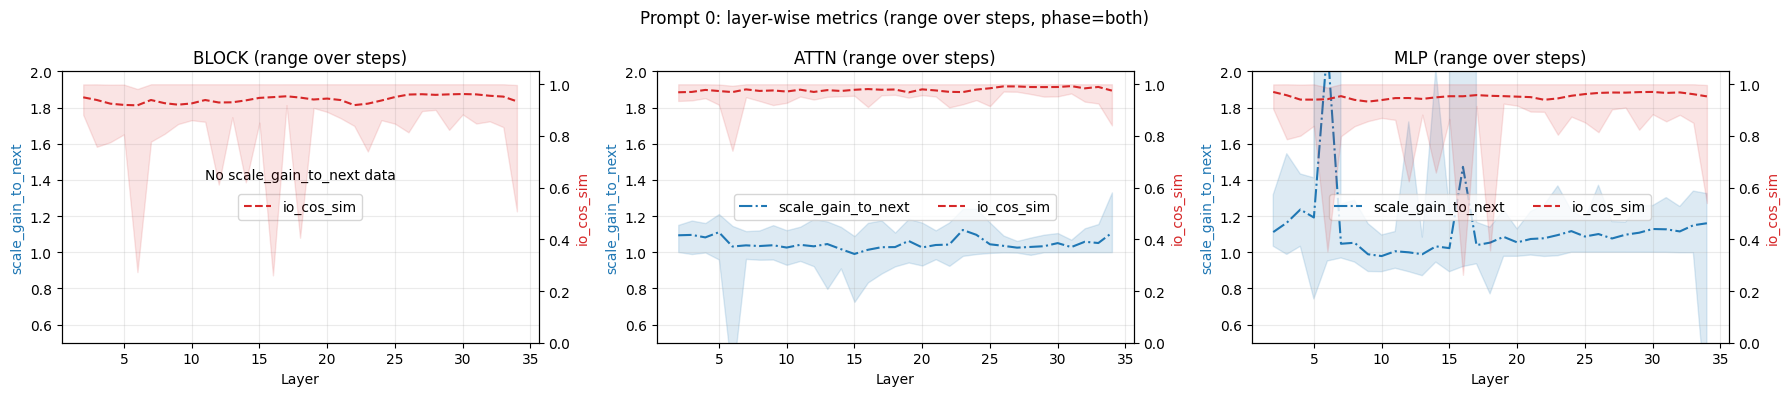

In [8]:
# NEW BLOCK: per-prompt plots, x-axis=layer, range over steps (min-max)
from pathlib import Path
import json
import matplotlib.pyplot as plt

# ---- config ----
# RESULT_PATH = Path('../results/generation_probe.json')
# PHASE = 'decode'   # 'decode' or 'prefill'
SAVE_FIG = False
# OUT_DIR = Path('../results')
LEFT_METRIC = 'scale_gain_to_next'  # or 'para_perp_ratio'
LEFT_LABEL = 'scale_gain_to_next' if LEFT_METRIC == 'scale_gain_to_next' else 'para_perp_ratio'
TRIM_EDGE_LAYERS = False
TRIM_EDGE_LAYERS = True

start_layer = 2

# -----------------

data = json.loads(RESULT_PATH.read_text(encoding='utf-8'))
runs = data['runs'] if 'runs' in data else [data]
print(f'loaded runs: {len(runs)} from {RESULT_PATH}')


def pick_steps(run, phase='decode'):
    timeline = run.get('timeline') or []
    if timeline:
        picked = [s for s in timeline if s.get('phase') == phase]
        return picked if picked else timeline
    if phase == 'prefill':
        prefill = run.get('prefill_steps') or []
        if prefill:
            return prefill
    return run.get('steps', [])


def collect_layerwise_from_layer_metrics(steps, value_key):
    by_layer = {}
    for s in steps:
        for m in (s.get('layer_metrics') or []):
            l = m.get('layer')
            v = m.get(value_key)
            if l is None or v is None:
                continue
            by_layer.setdefault(int(l), []).append(float(v))
    layers = sorted(by_layer)
    if TRIM_EDGE_LAYERS and len(layers) > 2:
        layers = layers[start_layer:-1]
    means = [sum(by_layer[l]) / len(by_layer[l]) for l in layers]
    mins = [min(by_layer[l]) for l in layers]
    maxs = [max(by_layer[l]) for l in layers]
    return layers, means, mins, maxs


def collect_layerwise_from_sublayer(steps, metric_key, value_key):
    by_layer = {}
    for s in steps:
        for item in (s.get('sublayer_metrics') or []):
            l = item.get('layer')
            v = (item.get(metric_key) or {}).get(value_key)
            if l is None or v is None:
                continue
            by_layer.setdefault(int(l), []).append(float(v))
    layers = sorted(by_layer)
    if TRIM_EDGE_LAYERS and len(layers) > 2:
        layers = layers[start_layer:-1]
    means = [sum(by_layer[l]) / len(by_layer[l]) for l in layers]
    mins = [min(by_layer[l]) for l in layers]
    maxs = [max(by_layer[l]) for l in layers]
    return layers, means, mins, maxs


series = [('block', 'BLOCK', 'block_update'), ('attn', 'ATTN', 'attn_update'), ('mlp', 'MLP', 'mlp_update')]

for prompt_idx, run in enumerate(runs):
    steps = pick_steps(run, phase=PHASE)
    if not steps:
        print(f'prompt {prompt_idx}: no steps ({PHASE}), skipped')
        continue

    has_sublayer = any(('sublayer_metrics' in s and s['sublayer_metrics']) for s in steps)
    has_layer = any(('layer_metrics' in s and s['layer_metrics']) for s in steps)
    print(f'prompt {prompt_idx}: steps={len(steps)}, phase={PHASE}, has_sublayer={has_sublayer}, has_layer={has_layer}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=False)

    for ax, (name, title, metric_key) in zip(axes, series):
        used_layer_left_fallback = False
        used_layer_cos_fallback = False

        if has_sublayer:
            if name == 'block':
                # block: prefer block_update in sublayer metrics
                x_l, mean_l, min_l, max_l = collect_layerwise_from_sublayer(steps, 'block_update', LEFT_METRIC)
                x_c, mean_c, min_c, max_c = collect_layerwise_from_sublayer(steps, 'block_update', 'io_cos_sim')
                if has_layer and not x_l:
                    x_l, mean_l, min_l, max_l = collect_layerwise_from_layer_metrics(steps, LEFT_METRIC)
                    used_layer_left_fallback = True
                if has_layer and not x_c:
                    x_c, mean_c, min_c, max_c = collect_layerwise_from_layer_metrics(steps, 'io_cos_sim')
                    used_layer_cos_fallback = True
            else:
                x_l, mean_l, min_l, max_l = collect_layerwise_from_sublayer(steps, metric_key, LEFT_METRIC)
                x_c, mean_c, min_c, max_c = collect_layerwise_from_sublayer(steps, metric_key, 'io_cos_sim')
        else:
            x_l, mean_l, min_l, max_l = collect_layerwise_from_layer_metrics(steps, LEFT_METRIC)
            x_c, mean_c, min_c, max_c = collect_layerwise_from_layer_metrics(steps, 'io_cos_sim')

        if x_l:
            ax.plot(x_l, mean_l, color='tab:blue', linestyle='-.', label=f'{LEFT_LABEL}')
            ax.fill_between(x_l, min_l, max_l, color='tab:blue', alpha=0.15, label='_nolegend_')
        else:
            ax.text(0.5, 0.62, f'No {LEFT_LABEL} data', ha='center', va='center', transform=ax.transAxes)

        ax2 = ax.twinx()
        if x_c:
            ax2.plot(x_c, mean_c, color='tab:red', linestyle='--', label='io_cos_sim')
            ax2.fill_between(x_c, min_c, max_c, color='tab:red', alpha=0.12, label='_nolegend_')
        else:
            ax.text(0.5, 0.42, 'No cos data', ha='center', va='center', transform=ax.transAxes)

        ax.set_title(f'{title} (range over steps)')
        ax.set_xlabel('Layer')
        ax.set_ylabel(LEFT_LABEL, color='tab:blue')
        ax.grid(alpha=0.25)
        ax.set_ylim(0.5, 2)

        ax2.set_ylabel('io_cos_sim', color='tab:red')
        ax2.set_ylim(0, 1.05)

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        if lines1 or lines2:
            ax.legend(lines1 + lines2, labels1 + labels2, ncol=2, loc='center')

        if used_layer_left_fallback:
            ax.text(0.01, 0.02, f'{LEFT_LABEL} from layer_metrics', transform=ax.transAxes, fontsize=8, color='tab:blue')
        if used_layer_cos_fallback:
            ax.text(0.01, 0.08, 'cos from layer_metrics', transform=ax.transAxes, fontsize=8, color='tab:red')

    fig.suptitle(f'Prompt {prompt_idx}: layer-wise metrics (range over steps, phase={PHASE})')
    fig.tight_layout()

    if SAVE_FIG:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out_path = OUT_DIR / f'prompt{prompt_idx}_{PHASE}_layerwise_range.png'
        fig.savefig(out_path, dpi=150)
        print(f'saved: {out_path}')

    plt.show()
    break


loaded runs: 12 from /mnt/bn/seed-aws-va/shwai.he/demystifying-transformers-main/results/generation_logits/Qwen3-4B-Instruct-2507-modeboth-tokens128.json
prompt 0: steps=171, phase=both, has_sublayer=True, has_layer=False


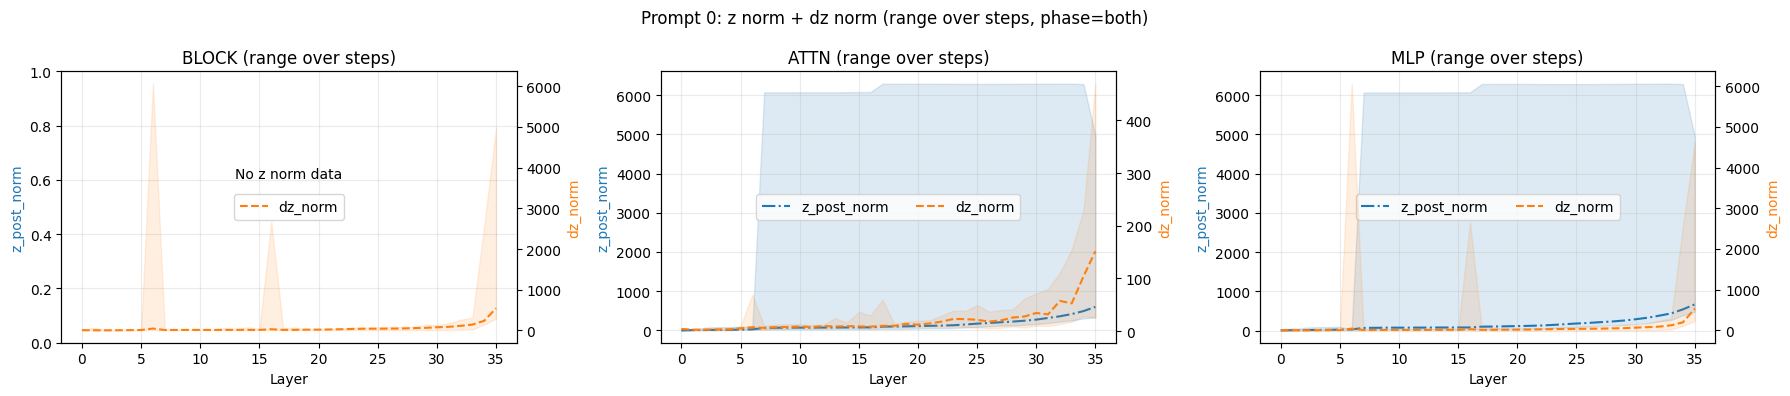

In [6]:
# NEW BLOCK: z norm + dz norm (range over steps), per prompt, layer-wise
from pathlib import Path
import json
import matplotlib.pyplot as plt

# ---- config ----
# RESULT_PATH = Path('../results/generation_probe.json')
# PHASE = 'decode'   # 'decode' or 'prefill'
SAVE_FIG = False
OUT_DIR = Path('../results')
TRIM_EDGE_LAYERS = False
# -----------------

data = json.loads(RESULT_PATH.read_text(encoding='utf-8'))
runs = data['runs'] if 'runs' in data else [data]
print(f'loaded runs: {len(runs)} from {RESULT_PATH}')


def pick_steps(run, phase='decode'):
    timeline = run.get('timeline') or []
    if timeline:
        picked = [s for s in timeline if s.get('phase') == phase]
        return picked if picked else timeline
    if phase == 'prefill':
        prefill = run.get('prefill_steps') or []
        if prefill:
            return prefill
    return run.get('steps', [])


def collect_layerwise_from_layer_metrics(steps, value_key):
    by_layer = {}
    for s in steps:
        for m in (s.get('layer_metrics') or []):
            l = m.get('layer')
            v = m.get(value_key)
            if l is None or v is None:
                continue
            by_layer.setdefault(int(l), []).append(float(v))
    layers = sorted(by_layer)
    if TRIM_EDGE_LAYERS and len(layers) > 2:
        layers = layers[1:-1]
    means = [sum(by_layer[l]) / len(by_layer[l]) for l in layers]
    mins = [min(by_layer[l]) for l in layers]
    maxs = [max(by_layer[l]) for l in layers]
    return layers, means, mins, maxs


def collect_layerwise_from_sublayer(steps, metric_key, value_key):
    by_layer = {}
    for s in steps:
        for item in (s.get('sublayer_metrics') or []):
            l = item.get('layer')
            v = (item.get(metric_key) or {}).get(value_key)
            if l is None or v is None:
                continue
            by_layer.setdefault(int(l), []).append(float(v))
    layers = sorted(by_layer)
    if TRIM_EDGE_LAYERS and len(layers) > 2:
        layers = layers[1:-1]
    means = [sum(by_layer[l]) / len(by_layer[l]) for l in layers]
    mins = [min(by_layer[l]) for l in layers]
    maxs = [max(by_layer[l]) for l in layers]
    return layers, means, mins, maxs


series = [('block', 'BLOCK', 'block_update'), ('attn', 'ATTN', 'attn_update'), ('mlp', 'MLP', 'mlp_update')]

for prompt_idx, run in enumerate(runs):
    steps = pick_steps(run, phase=PHASE)
    if not steps:
        print(f'prompt {prompt_idx}: no steps ({PHASE}), skipped')
        continue

    has_sublayer = any(('sublayer_metrics' in s and s['sublayer_metrics']) for s in steps)
    has_layer = any(('layer_metrics' in s and s['layer_metrics']) for s in steps)
    print(f'prompt {prompt_idx}: steps={len(steps)}, phase={PHASE}, has_sublayer={has_sublayer}, has_layer={has_layer}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=False)

    for ax, (name, title, metric_key) in zip(axes, series):
        used_layer_z_fallback = False
        used_layer_dz_fallback = False

        if has_sublayer:
            if name == 'block':
                x_z, mean_z, min_z, max_z = collect_layerwise_from_sublayer(steps, 'block_update', 'z_post_norm')
                x_dz, mean_dz, min_dz, max_dz = collect_layerwise_from_sublayer(steps, 'block_update', 'dz_norm')
                if has_layer and not x_z:
                    x_z, mean_z, min_z, max_z = collect_layerwise_from_layer_metrics(steps, 'z_post_norm')
                    used_layer_z_fallback = True
                if has_layer and not x_dz:
                    x_dz, mean_dz, min_dz, max_dz = collect_layerwise_from_layer_metrics(steps, 'dz_norm')
                    used_layer_dz_fallback = True
            else:
                x_z, mean_z, min_z, max_z = collect_layerwise_from_sublayer(steps, metric_key, 'z_post_norm')
                x_dz, mean_dz, min_dz, max_dz = collect_layerwise_from_sublayer(steps, metric_key, 'dz_norm')
        else:
            x_z, mean_z, min_z, max_z = collect_layerwise_from_layer_metrics(steps, 'z_post_norm')
            x_dz, mean_dz, min_dz, max_dz = collect_layerwise_from_layer_metrics(steps, 'dz_norm')

        if x_z:
            ax.plot(x_z, mean_z, color='tab:blue', linestyle='-.', label='z_post_norm')
            ax.fill_between(x_z, min_z, max_z, color='tab:blue', alpha=0.15, label='_nolegend_')
        else:
            ax.text(0.5, 0.62, 'No z norm data', ha='center', va='center', transform=ax.transAxes)

        ax2 = ax.twinx()
        if x_dz:
            ax2.plot(x_dz, mean_dz, color='tab:orange', linestyle='--', label='dz_norm')
            ax2.fill_between(x_dz, min_dz, max_dz, color='tab:orange', alpha=0.12, label='_nolegend_')
        else:
            ax.text(0.5, 0.42, 'No dz norm data', ha='center', va='center', transform=ax.transAxes)

        ax.set_title(f'{title} (range over steps)')
        ax.set_xlabel('Layer')
        ax.set_ylabel('z_post_norm', color='tab:blue')
        ax.grid(alpha=0.25)

        ax2.set_ylabel('dz_norm', color='tab:orange')

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        if lines1 or lines2:
            ax.legend(lines1 + lines2, labels1 + labels2, ncol=2, loc='center')

        if used_layer_z_fallback:
            ax.text(0.01, 0.02, 'z norm from layer_metrics', transform=ax.transAxes, fontsize=8, color='tab:blue')
        if used_layer_dz_fallback:
            ax.text(0.01, 0.08, 'dz norm from layer_metrics', transform=ax.transAxes, fontsize=8, color='tab:orange')

    fig.suptitle(f'Prompt {prompt_idx}: z norm + dz norm (range over steps, phase={PHASE})')
    fig.tight_layout()

    if SAVE_FIG:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out_path = OUT_DIR / f'prompt{prompt_idx}_{PHASE}_layerwise_znorm_dznorm_range.png'
        fig.savefig(out_path, dpi=150)
        print(f'saved: {out_path}')

    plt.show()
    break
